In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Load data

In [2]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

In [3]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df.sort_values(by="fam", ascending=False, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref

def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' a ['metodo', 'umbral']."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out



In [4]:
EXP_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/"

UFOLD_DATA = EXP_PATH + "UFold/SILVER/100_epochs_test_exact.csv"
SINCFOLD_DATA = EXP_PATH + "sincFold/SILVER/train_and_spy/last_epoch/sincFold_testnspy_15_epochs.csv"
REDFOLD_DATA = EXP_PATH + "REDFold/SILVER/200_epochs_test.csv"
RESNET_OH_DATA = EXP_PATH + "rna-llm-folding/SILVER/test_tables/OneHot_15_epochs_test.csv"
RESNET_RINALMO_DATA = EXP_PATH + "rna-llm-folding/SILVER/test_tables/RiNALMo_15_epochs_test.csv"

data_paths = {
    "UFold": UFOLD_DATA,
    "sincFold": SINCFOLD_DATA,
    "REDFold": REDFOLD_DATA,
    "ResNet_OH": RESNET_OH_DATA,
    "ResNet_RINALMo": RESNET_RINALMO_DATA,
}



In [5]:

dfs, df_refs, dfl = {}, {}, {}
for name, path in data_paths.items():
    dfs[name], df_refs[name] = get_data(path)
    df_refs[name].set_index("fam")["famfold"].to_dict()
    dfl[name] = dfs[name].melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    ) 
    dfl[name] = add_metodo_umbral(dfl[name]) 
    print(f"for {name} are {dfl[name].shape[0]} rows")

for UFold are 81 rows
for sincFold are 81 rows
for REDFold are 81 rows
for ResNet_OH are 81 rows
for ResNet_RINALMo are 81 rows


# PLOT

# Definitions and Functions

In [ ]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}

def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend_in_axis(empty_ax, axes):
    """Construye leyenda combinada y la dibuja dentro de `empty_ax`."""
    handles, labels = [], []
 
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        if ax.get_legend():
            ax.get_legend().remove()
 
    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u)
        for u in PALETTE
    ]
    handles.extend(color_handles)
    labels.extend([h.get_label() for h in color_handles])
    uniq = dict(zip(labels, handles))
 
    empty_ax.axis("off")

    # dibujar leyenda dentro del eje vacío
    empty_ax.legend(
        uniq.values(),
        uniq.keys(),
        loc="center",
        ncol=2,
        frameon=False,
        fontsize=15
    )

## Figure

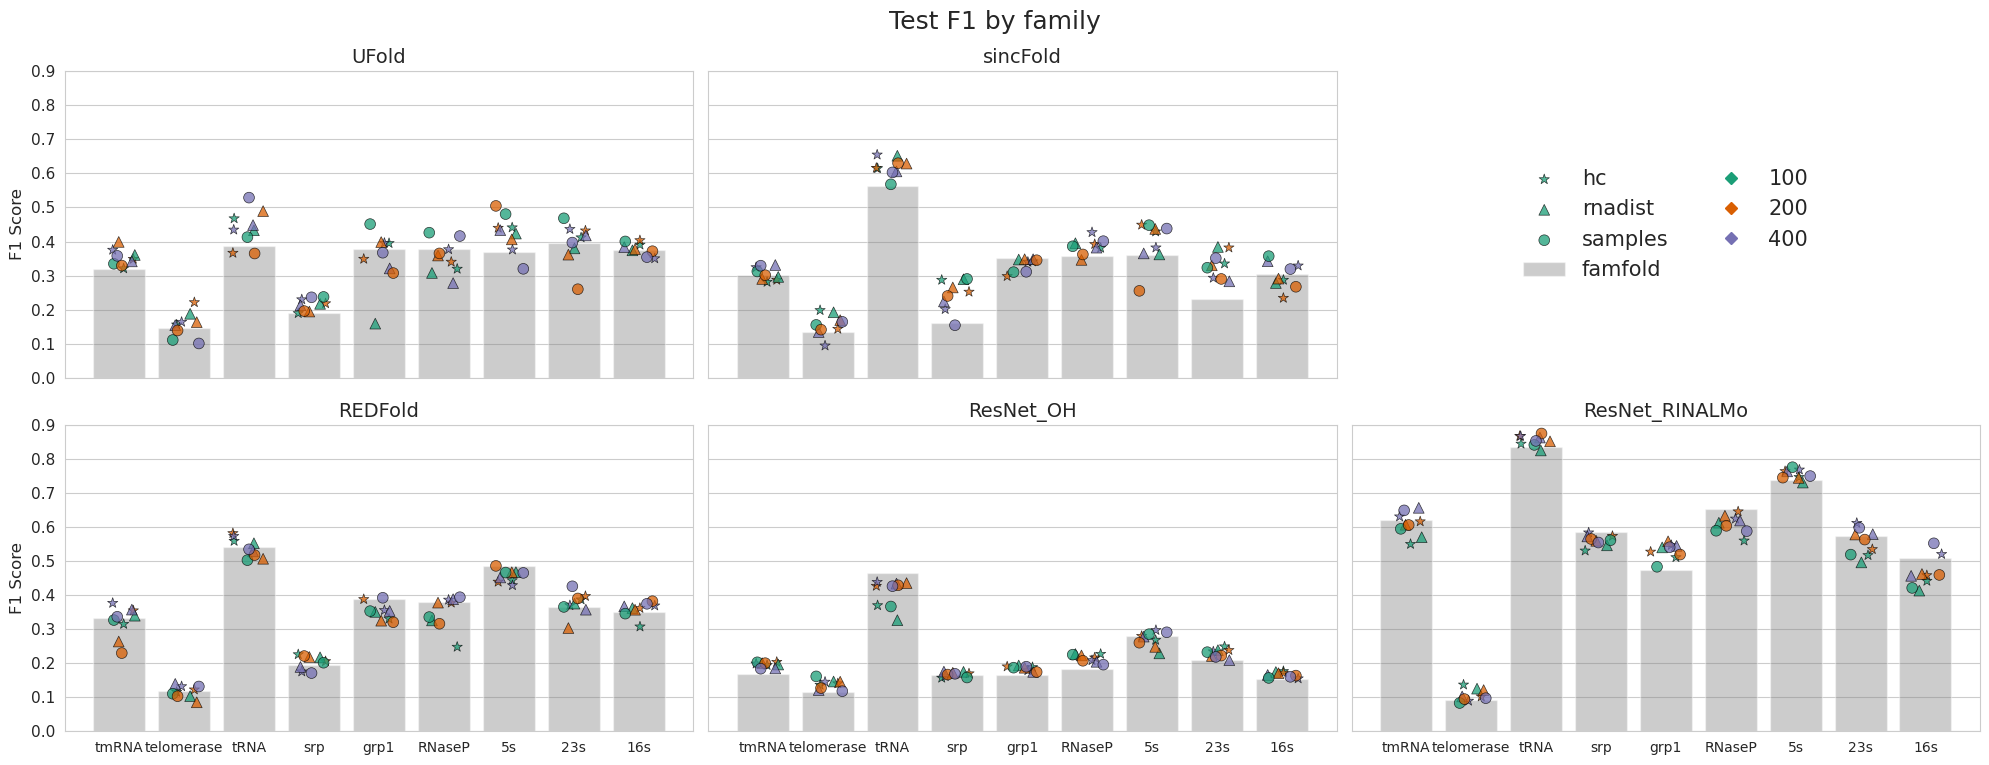

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- configuraciones ---
sns.set_style("whitegrid")

n_models = 5
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

fam_order = sorted(next(iter(dfl.values()))["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

for i, (name, ax) in enumerate(zip(data_paths.keys(), axes)):
    if i >= 2:
        i +=1
        ax = axes[i]
     

    ax_bar = ax
    sns.barplot(
        data=df_refs[name],
        x="fam",
        y="famfold",
        color="gray",
        alpha=0.4,
        errorbar=None,
        ax=ax_bar,
        label="famfold",
    )
    strip(ax_bar, dfl[name], fam_map)

    ax_bar.set_ylim(0, 0.9)
    ax_bar.set_title(f"{name}", fontsize=14)
    ax_bar.set_ylabel("F1 Score", fontsize=12)
    ax_bar.yaxis.set_tick_params(labelsize=11)

    # Etiquetas comunes
    ax_bar.set_xlabel("")
    ax_bar.set_xticks(range(len(fam_order)))
    ax_bar.set_xticklabels(fam_order, fontsize=10)


# --- Ajustes finales ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

empty_ax = axes[2]   
combined_legend_in_axis(empty_ax, axes)
fig.suptitle("Test F1 by family", fontsize=18)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


# Add heatmap

In [14]:


REPO_PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/"

# SincFold

SF_REL = REPO_PATH + "sincFold/SILVER/train_and_spy/last_epoch/sincFold_relf1.csv"
SF_OV_REL = REPO_PATH + "sincFold/SILVER/sincFold_ovs_w_val_20_relf1.csv"

# rna-llm

RNA_LLM_REL = REPO_PATH + "rna-llm-folding/SILVER/rel_f1_tables/"
RNA_LLM_OV_REL = REPO_PATH + "rna-llm-folding/SILVER/rel_f1_tables_ov/"

REDFOLD_REL = REPO_PATH + "REDFold/SILVER/200_epochs_relf1.csv"
UFOLD_REL = REPO_PATH + "UFold/SILVER/100_epochs_test_rel_f1_exact.csv"
# UFOLD_REL_lr = REPO_PATH + "UFold/SILVER/0_long_run100/100_epochs_test_rel_f1_exact.csv"
oh = "OneHot_15_epochs_relf1.csv"
rinalmo = "RiNALMo_15_epochs_relf1.csv"
sincfold = pd.read_csv(SF_REL, index_col=0)
sincfold_ov = pd.read_csv(SF_OV_REL, index_col=0)

rna_oh = pd.read_csv(RNA_LLM_REL + oh, index_col=0)
rna_oh_ov = pd.read_csv(RNA_LLM_OV_REL + oh, index_col=0)

rna_rinalmo = pd.read_csv(RNA_LLM_REL + rinalmo, index_col=0)
rna_rinalmo_ov = pd.read_csv(RNA_LLM_OV_REL + rinalmo, index_col=0)

redfold = pd.read_csv(REDFOLD_REL, index_col=0)
ufold = pd.read_csv(UFOLD_REL, index_col=0)
# ufold_lr = pd.read_csv(UFOLD_REL_lr, index_col=0)

In [15]:
# Lista con los dataframes y sus nombres
dfs = {
    "sincFold": sincfold,
    "ResNet\n One-Hot": rna_oh,
    "ResNet\n RiNALMo": rna_rinalmo,
    "REDFold": redfold,
    "UFold": ufold,
    # "UFold_LR": ufold_lr,
}

# Transformar cada df: usar 'modelo' como índice y renombrar 'rel_f1'
for name, df in dfs.items():
    dfs[name] = df.set_index("modelo").rename(columns={"rel_f1": name})

# Unirlos por el índice 'modelo'
df_final = pd.concat(dfs.values(), axis=1)

# Cambiar nombre del índice
df_final.index.name = "metodo"
df_final.sort_values(by="metodo", inplace=True)
df_final

,sincFold,ResNet\n One-Hot,ResNet\n RiNALMo,REDFold,UFold
metodo,,,,,
hc_100,1.209602,1.085338,1.002279,0.940601,1.046737
hc_200,1.141762,1.108329,1.010604,1.027422,1.095534
hc_400,1.083022,1.087027,1.029806,1.009881,1.078213
rnadist_100,1.224632,1.078726,0.995386,0.979145,0.999120
rnadist_200,1.169515,1.094044,1.039072,0.912625,1.072783
rnadist_400,1.107971,1.044027,1.025306,1.009766,1.024511
samples_100,1.195751,1.096974,0.948652,0.957442,1.107824
samples_200,1.053404,1.052839,0.993077,0.941039,0.969386
samples_400,1.123927,1.044917,1.029185,1.025665,1.031286


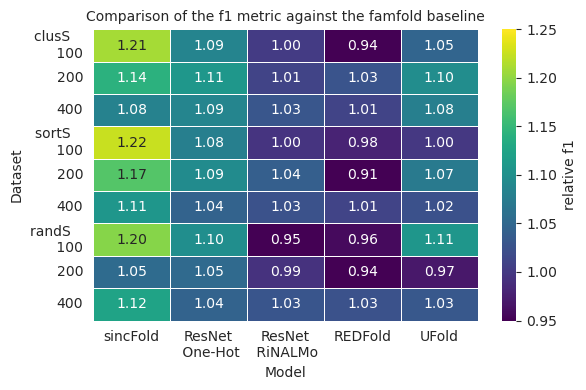

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
df_final.index = [
    'clusS   \n 100',
    '200',
    '400',    
    'sortS   \n 100',
    '200',
    '400',    
    'randS   \n 100',
    '200',
    '400',
    ]
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_final,
    annot=True,  # Muestra los valores
    fmt=".2f",  # Formato de números
    cmap="viridis",  # Paleta de colores
    linewidths=0.5,  # Separadores de celdas
    cbar_kws={"label": "relative f1"},  # Etiqueta de la barra de color
    vmin=0.95,
    vmax=1.25,
)
plt.title("Comparison of the f1 metric against the famfold baseline", fontsize=10)
plt.ylabel("Dataset")
plt.xlabel("Model")
plt.yticks(rotation=0)
plt.tight_layout() 
plt.show()

In [29]:
ss_map = {
    "rnadist" : "sortS",
    "hc" : "clusS",
    "samples" : "randS",
}

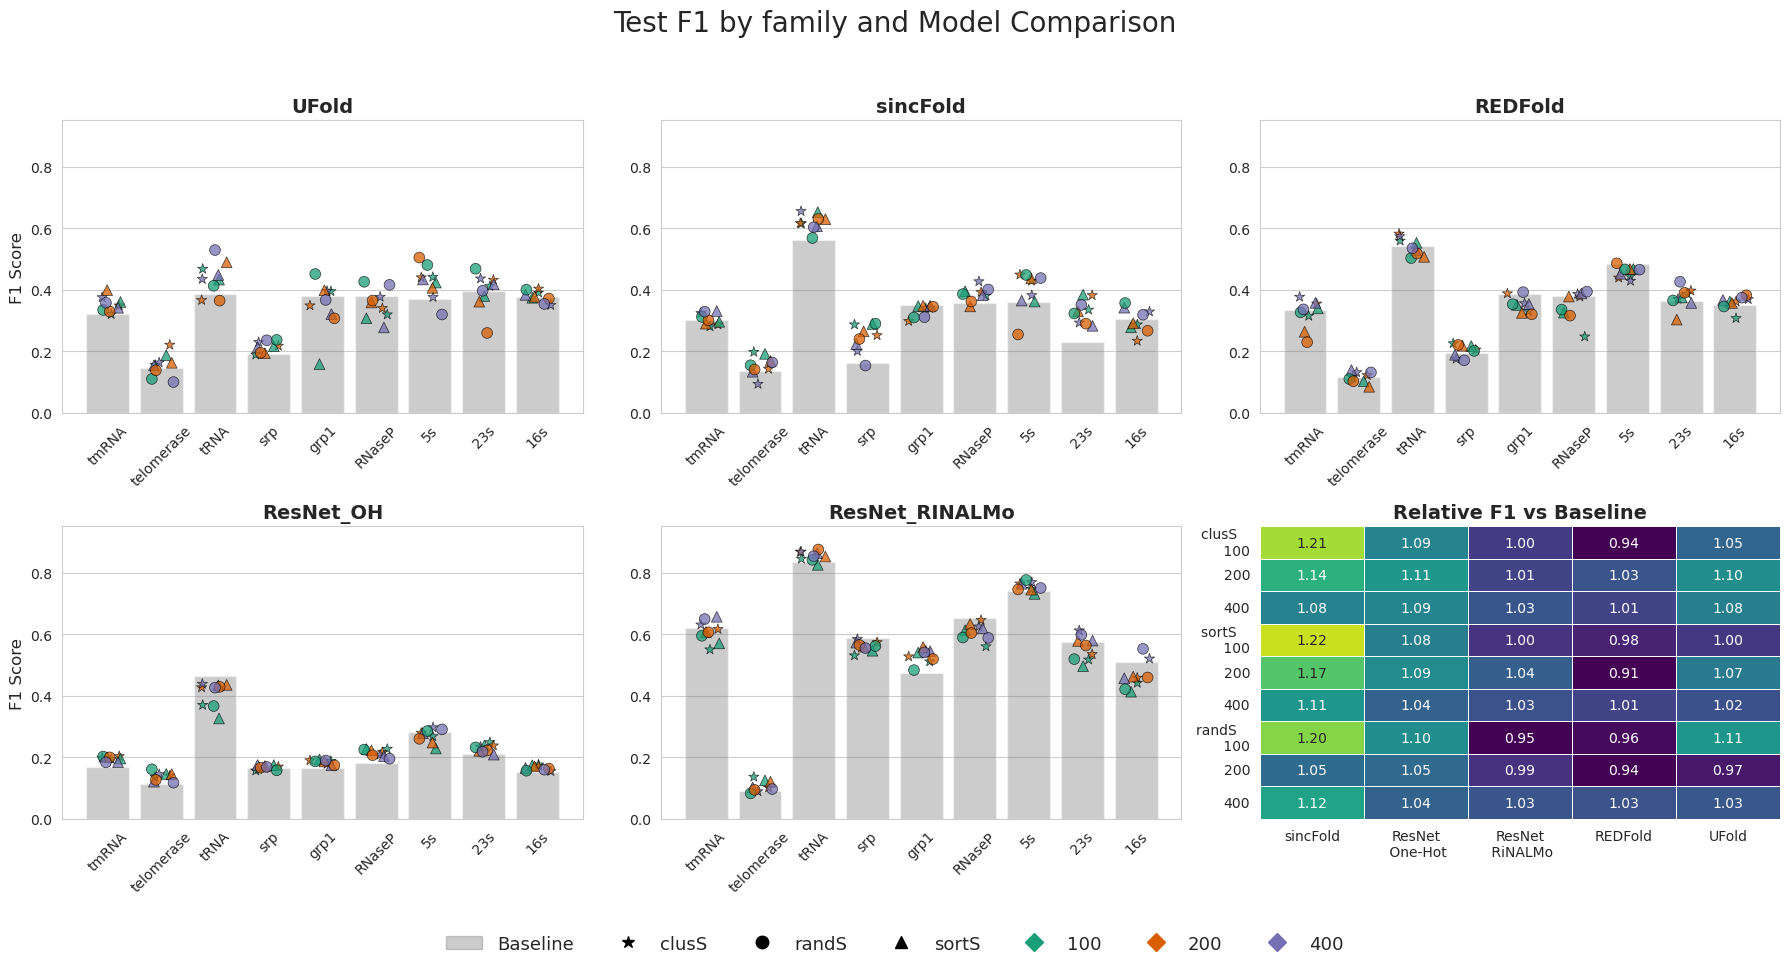

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- TUS CONFIGURACIONES ---
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}
sns.set_style("whitegrid")

def strip(ax, df, fam_map, seed=0):
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )

# ==========================================
# SETUP DE LA FIGURA
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

model_keys = list(data_paths.keys())

# ==========================================
# 1. PLOTEO DE MODELOS (Paneles 0 a 4)
# ==========================================
for i, name in enumerate(model_keys):
    ax = axes[i]
    
    # A. Barplot (Baseline)
    sns.barplot(
        data=df_refs[name],
        x="fam",
        y="famfold",
        color="gray",
        alpha=0.4,
        errorbar=None,
        ax=ax
    )
    
    # B. Strip plot (Tu función)
    strip(ax, dfl[name], fam_map)

    # C. Estética
    ax.set_ylim(0, 0.95)
    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    
    if i % 3 == 0:
        ax.set_ylabel("F1 Score", fontsize=12)
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order, fontsize=10, rotation=45)

    # Limpiamos leyendas internas para que no molesten
    if ax.get_legend():
        ax.get_legend().remove()

# ==========================================
# 2. PLOTEO DEL HEATMAP (Panel 5)
# ==========================================
ax_heat = axes[5]
sns.heatmap(
    df_final,
    annot=True, fmt=".2f", cmap="viridis", linewidths=0.5,
    cbar=False,
#    cbar_kws={"label": "Relative F1", "shrink": 0.8},
    vmin=0.95, vmax=1.25,
    ax=ax_heat, annot_kws={"size": 10}
)
ax_heat.set_title("Relative F1 vs Baseline", fontsize=14, fontweight='bold')
ax_heat.set_ylabel("")
ax_heat.set_xlabel("")

# ==========================================
# 3. CONSTRUCCIÓN MANUAL DE LA LEYENDA
# ==========================================

# Grupo A: Baseline
h_baseline = [Patch(color='gray', alpha=0.4, label='Baseline')]

# Grupo B: Métodos (Formas) - Usamos color negro para representar solo la forma
h_shapes = [
    Line2D([], [], color='black', marker=marker, linestyle='', markersize=9, label=ss_map[name])
    for name, marker in MARKERS.items()
]

# Grupo C: Umbrales (Colores) - Usamos círculo sólido para representar el color
h_colors = [
    Line2D([], [], color=color, marker='D', linestyle='', markersize=9, label=f"{thr}")
    for thr, color in PALETTE.items()
]

# Combinamos todo en el orden deseado
legend_handles = h_baseline + h_shapes + h_colors

fig.suptitle("Test F1 by family and Model Comparison", fontsize=20, y=0.98)

# Colocamos la leyenda abajo
fig.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02),
    ncol=7, # Número alto de columnas para que quede horizontal
    frameon=False, 
    fontsize=13
)

# Ajuste de márgenes (rect: izq, abajo, der, arriba)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

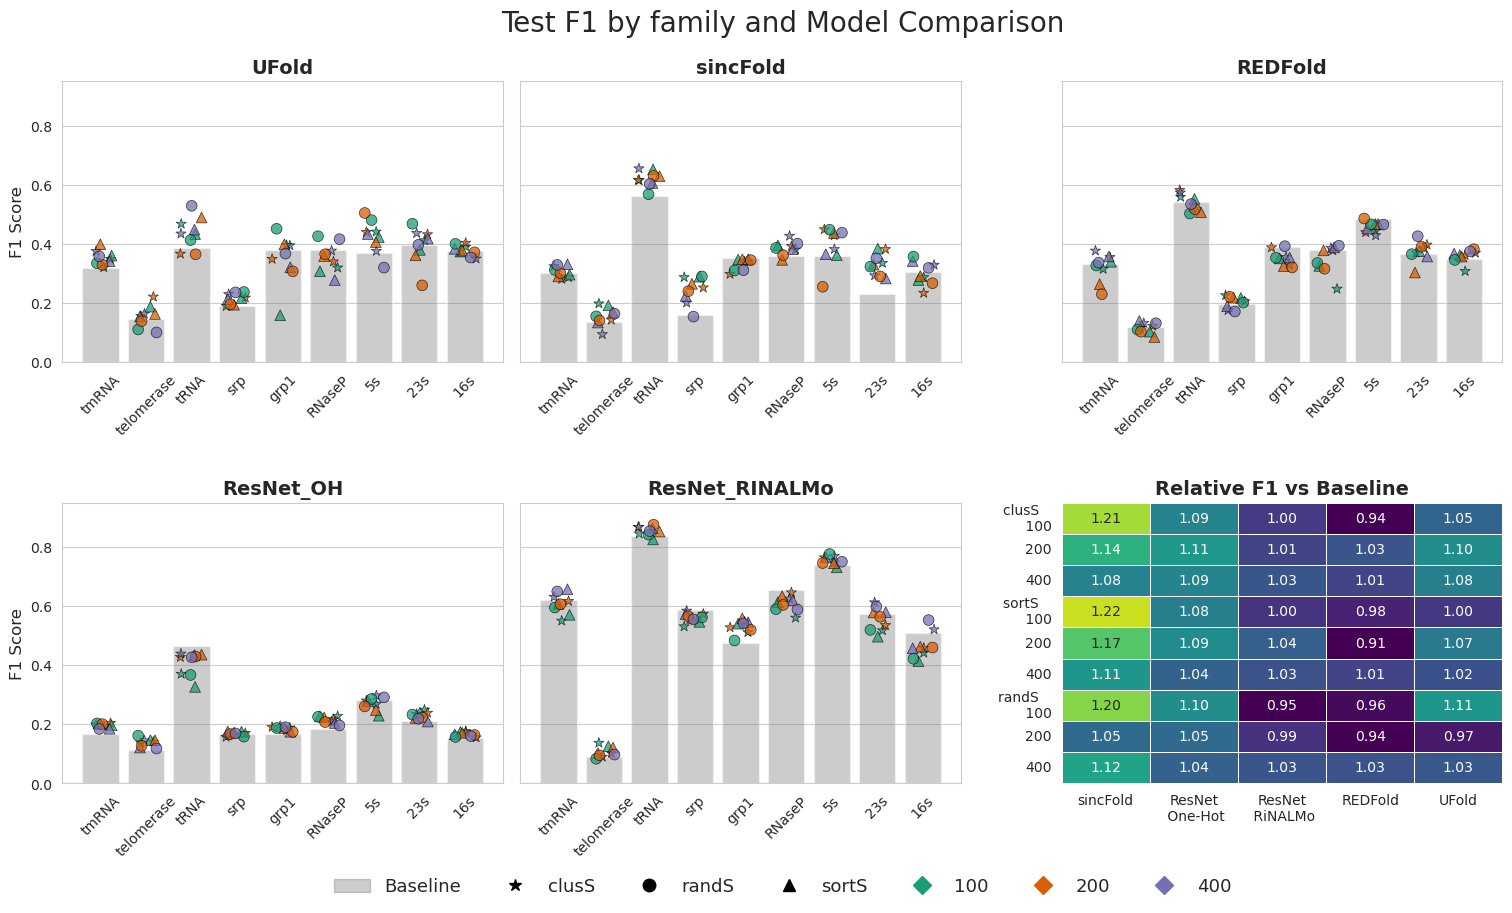

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec # Importamos GridSpec

# --- TUS CONFIGURACIONES ---
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}
sns.set_style("whitegrid")

def strip(ax, df, fam_map, seed=0):
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )

# ==========================================
# SETUP DE LA FIGURA CON GRIDSPEC
# ==========================================
fig = plt.figure(figsize=(16, 9))

# Definimos 4 columnas: 
# Col 0: Gráfico
# Col 1: Gráfico
# Col 2: ESPACIADOR (ancho 0.15)
# Col 3: Gráfico (Heatmap/Modelo 2)
gs = gridspec.GridSpec(2, 4, figure=fig, 
                       width_ratios=[1, 1, 0.15, 1], # La 3ra col es finita
                       wspace=0.05,  # Espacio muy fino entre columnas activas
                       hspace=0.5)  # Espacio vertical normal

model_keys = list(data_paths.keys())

# Mapa de coordenadas para los 5 modelos. 
# Saltamos la columna índice 2 (el espaciador)
# Formato: (fila, columna)
plot_coords = [
    (0, 0), (0, 1), (0, 3), # Fila 0: Mod0, Mod1, --, Mod2
    (1, 0), (1, 1)          # Fila 1: Mod3, Mod4, --, (Heatmap va en 1,3)
]

# Lista para guardar los ejes creados y poder hacer sharey
created_axes = []

# ==========================================
# 1. PLOTEO DE MODELOS
# ==========================================
for i, name in enumerate(model_keys):
    row, col = plot_coords[i]
    
    # Creamos el subplot en la celda específica
    ax = fig.add_subplot(gs[row, col])
    created_axes.append(ax)
    
    # --- LOGICA DE SHAREY MANUAL ---
    # Usamos el primer eje creado (ax0) como referencia para todos
    if (i != 0) and (i != 3):
        ax.sharey(created_axes[0])
        
        # Ocultar Eje Y si NO es la primera columna visual (Columna índice 0)
        # Nota: La columna 3 (derecha) también debería tener eje Y visible si está separada?
        # Generalmente, si está separada, queda mejor con su propio eje Y o sin él.
        # Aquí lo dejaremos SIN eje Y para que se vea limpio, salvo que quieras repetirlo.
        
        # Si NO estamos en la columna 0, quitamos los labels del eje Y
        if col != 0:
            plt.setp(ax.get_yticklabels(), visible=False)
            ax.set_ylabel("")
            
    else:
        # Eje 0 (Referencia)
        ax.set_ylabel("F1 Score", fontsize=12)

    # Caso especial: El gráfico de la derecha (col 3) está lejos. 
    # ¿Quieres que tenga eje Y? Si sí, descomenta esto:
    # if col == 3:
    #     plt.setp(ax.get_yticklabels(), visible=True)
    #     ax.set_ylabel("F1 Score", fontsize=12)


    # PLOTEO
    sns.barplot(data=df_refs[name], x="fam", y="famfold", color="gray", alpha=0.4, errorbar=None, ax=ax)
    strip(ax, dfl[name], fam_map)

    # ESTÉTICA
    ax.set_ylim(0, 0.95)
    ax.set_title(f"{name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order, fontsize=10, rotation=45)

    if ax.get_legend(): ax.get_legend().remove()

ax.set_ylabel("F1 Score", fontsize=12)

# ==========================================
# 2. PLOTEO DEL HEATMAP (En la celda (1, 3))
# ==========================================
ax_heat = fig.add_subplot(gs[1, 3]) # Fila 1, Columna 3 (Ultima)

sns.heatmap(
    df_final,
    annot=True, fmt=".2f", cmap="viridis", linewidths=0.5,
    cbar=False, vmin=0.95, vmax=1.25,
    ax=ax_heat, annot_kws={"size": 10}
)
ax_heat.set_title("Relative F1 vs Baseline", fontsize=14, fontweight='bold')
ax_heat.set_ylabel("")
ax_heat.set_xlabel("")
ax_heat.tick_params(left=False, bottom=False)

# ==========================================
# 3. LEYENDA
# ==========================================
h_baseline = [Patch(color='gray', alpha=0.4, label='Baseline')]
h_shapes = [Line2D([], [], color='black', marker=marker, linestyle='', markersize=9, label=ss_map[name]) for name, marker in MARKERS.items()]
h_colors = [Line2D([], [], color=color, marker='D', linestyle='', markersize=9, label=f"{thr}") for thr, color in PALETTE.items()]

legend_handles = h_baseline + h_shapes + h_colors
fig.suptitle("Test F1 by family and Model Comparison", fontsize=20, y=0.98)

fig.legend(
    handles=legend_handles,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.023),
    ncol=7, 
    frameon=False, 
    fontsize=13
)

# Ajustamos márgenes globales (GridSpec ya maneja los internos)
plt.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.12)

plt.show()